In [ ]:
import os, re, glob
import pandas as pd

#EDIT THIS: pathway to the folder for the cleaned data that should contain kestrels as well
FOLDER = "/Users/timjun/Desktop/USVI_2026/combined_data/0629_R3 cleaned output"

#Rules: these are parameters that can be changed based on assumptions after looking at the graphs 

CALIB_BUFFER_MIN = 20  #If a pocketlab is stopped within CALIB_BUFFER_MIN minutes of a kestrel, it is not penalized and the stopping point is the last pocketlab reading before the kestrel
CALIB_BACK_MIN   = 15   #If a pocketlab is stopped more than CALIB_BUFFER_MIN minutes before a kestrel, the stopping point is marked CALIB_BACK_MIN minutes before the kestrel
RESUME_BUFFER_MIN = 7   # a resume within RESUME_BUFFER_MIN  after a kestrel counts as the gap end
EDGE_TOL_MIN     = 2    # start/end times within 2 min are treated as "together"

#Nothing after this point needs to be edited
CALIB_BUFFER  = CALIB_BUFFER_MIN * 60
CALIB_BACK    = CALIB_BACK_MIN * 60
RESUME_BUFFER = RESUME_BUFFER_MIN * 60
EDGE_TOL      = EDGE_TOL_MIN * 60

#Handoffs: this was only a problem for one route (before we named pocketlabs). Only toggle on to True if you know that during the route, the initials changed but they were using the same pocketlab in order to concatnate the data.
MERGE_HANDOFFS = False
HANDOFFS = [
    ("10", "AM", ["HL", "CC"], "HL/CC"),
]


def route_of(name):
    m = re.search(r"R(\d+)", os.path.basename(name))
    return str(int(m.group(1))) if m else "?"


def load_kestrels(folder):
    """Every KESTREL csv -> its data start/end time and AM/PM (by its own timestamp)."""
    ks = []
    for p in glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True):
        if "kestrel" not in os.path.basename(p).lower():
            continue
        df = pd.read_csv(p, skiprows=3, dtype=str, keep_default_na=False)
        ts = pd.to_datetime(df.iloc[1:]["FORMATTED DATE_TIME"], errors="coerce").dropna()
        if ts.empty:
            continue
        k_s, k_e = ts.min(), ts.max()
        ks.append({"route": route_of(p), "ampm": "AM" if k_s.hour < 12 else "PM",
                   "start": k_s, "end": k_e, "file": os.path.basename(p)})
    return ks


def load_pocketlabs(folder):
    """Every cleaned pocketlab file -> timestamps + GPS/temp validity, tagged by initials & AM/PM."""
    pls = []
    for p in glob.glob(os.path.join(folder, "**", "*.xlsx"), recursive=True):
        b = os.path.basename(p)
        if not (b.startswith("combined_") and b.endswith("_cleaned.xlsx")):
            continue  # skip the "full_" combined file and non-cleaned copies
        df = pd.read_excel(p)
        ts = pd.to_datetime(df["date"].astype(str) + " " + df["time"].astype(str), errors="coerce")
        df = df.assign(_ts=ts).dropna(subset=["_ts"]).sort_values("_ts").reset_index(drop=True)
        if df.empty:
            continue
        lat = pd.to_numeric(df.get("latitude"), errors="coerce")
        lon = pd.to_numeric(df.get("longitude"), errors="coerce")
        temp = pd.to_numeric(df.get("temp_probe"), errors="coerce")
        gps_valid = lat.notna() & lon.notna() & (lat != 0) & (lon != 0)
        temp_valid = temp.notna() & (temp != 0)
        m = re.search(r"_(AM|PM)_", b)
        ampm = m.group(1) if m else ("AM" if df["_ts"].iloc[0].hour < 12 else "PM")
        # collector initials and pocketlab number (either may be blank on some routes)
        def first_value(colname):
            if colname not in df.columns:
                return ""
            vals = df[colname].dropna().astype(str).str.strip()
            vals = vals[~vals.isin(["", "nan", "NaN", "None"])]
            return vals.iloc[0] if not vals.empty else ""

        init = first_value("collector_initials")
        plnum = first_value("pocketlab")  # e.g. "PL17"; blank on early, unnumbered routes
        pls.append({"route": route_of(b), "ampm": ampm, "initials": init, "plnum": plnum,
                    "ts": df["_ts"], "gps": gps_valid, "temp": temp_valid})
    return pls


def merge_windows(wins):
    merged = []
    for s, e in sorted(wins):
        if merged and s <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], e))
        else:
            merged.append((s, e))
    return merged


def overlap_seconds(win, a, b):
    s, e = max(win[0], a), min(win[1], b)
    return max(0.0, (e - s).total_seconds())


def _device_label(p):
    """Label = initials + pocketlab number (e.g. 'TJ_10'). Drop whichever piece is missing."""
    parts = [x for x in (p.get("initials"), p.get("plnum")) if x and x != "?"]
    return "_".join(parts) if parts else "?"


def _merged_label(members, num=""):
    """Handoff label: all the collectors' initials joined by '/', plus the shared number
    (e.g. 'HL/CC_10'). Drop whichever piece is missing."""
    inits = "/".join(dict.fromkeys(
        m["initials"] for m in members if m.get("initials") and m["initials"] != "?"))
    parts = [x for x in (inits, num) if x]
    return "_".join(parts) if parts else "?"


def _combine(members, label):
    """Fuse several pocketlab records into one continuous track (a handoff)."""
    d = pd.concat(
        [pd.DataFrame({"ts": p["ts"].values, "gps": p["gps"].values, "temp": p["temp"].values})
         for p in members],
        ignore_index=True,
    ).sort_values("ts").reset_index(drop=True)
    return {"label": label, "route": members[0]["route"], "ampm": members[0]["ampm"],
            "ts": d["ts"], "gps": d["gps"], "temp": d["temp"]}


def apply_handoffs(group, route, ampm):
    """Return the effective device tracks for this route+AM/PM.
    A handoff (one physical pocketlab used by two collectors) is merged into one track:
      1. numbered routes  -> auto-merge files that share the same pocketlab number
      2. unnumbered routes -> use the manual HANDOFFS list (by collector initials)
    Every returned track carries a 'label' for the output row."""
    if not MERGE_HANDOFFS:
        return [{**p, "label": _device_label(p)} for p in group]

    result, used = [], set()

    # 1) auto-merge by pocketlab number (later routes that were numbered)
    by_num = {}
    for p in group:
        if p.get("plnum"):
            by_num.setdefault(p["plnum"], []).append(p)
    for num, members in by_num.items():
        if len(members) >= 2:
            result.append(_combine(members, _merged_label(members, num)))
            used.update(id(p) for p in members)

    # 2) manual handoffs by initials (earlier, unnumbered routes)
    for (r, ap, names, label) in HANDOFFS:
        if r != route or ap != ampm:
            continue
        members = [p for p in group if p["initials"] in names and id(p) not in used]
        if len(members) >= 2:
            result.append(_combine(members, label))
            used.update(id(p) for p in members)

    # 3) everyone not part of a handoff, labeled by number-or-initials
    for p in group:
        if id(p) not in used:
            result.append({**p, "label": _device_label(p)})
    return result


def group_analysis(folder):
    """Per-(route, AM/PM) details reused by both the table and the plots:
    kestrel break windows, route start/end, and each pocketlab's counted span,
    valid masks, and percentages."""
    kest = load_kestrels(folder)
    pls = load_pocketlabs(folder)
    groups = []

    # AM and PM are handled as separate routes
    for (route, ampm) in sorted(set((p["route"], p["ampm"]) for p in pls)):
        group = [p for p in pls if p["route"] == route and p["ampm"] == ampm]
        gk = [k for k in kest if k["route"] == route and k["ampm"] == ampm]

        true_start = min(p["ts"].iloc[0] for p in group)   # earliest pocketlab start
        true_end = max(p["ts"].iloc[-1] for p in group)     # latest pocketlab end
        all_ts = pd.concat([p["ts"] for p in group])

        # build a route-wide break window for each kestrel
        wins = []
        for k in gk:
            Ks, Ke = k["start"], k["end"]
            pre = all_ts[all_ts < Ks]
            if len(pre):
                L = pre.max()  # last pocketlab reading before the kestrel
                gap_start = L if L >= Ks - pd.Timedelta(seconds=CALIB_BUFFER) else Ks - pd.Timedelta(seconds=CALIB_BACK)
            else:
                gap_start = Ks
            post = all_ts[all_ts > Ke]
            if len(post):
                F = post.min()  # first pocketlab reading after the kestrel
                gap_end = F if F <= Ke + pd.Timedelta(seconds=RESUME_BUFFER) else Ke
            else:
                gap_end = Ke
            if gap_end > gap_start:
                wins.append((gap_start, gap_end))
        wins = merge_windows(wins)

        # merge handoff collectors into one track (route windows above are unchanged)
        eff_group = apply_handoffs(group, route, ampm)

        members = []
        for p in eff_group:
            own_start, own_end = p["ts"].iloc[0], p["ts"].iloc[-1]

            # start: if this pocketlab started >2 min after the earliest, it lost early data
            counted_start = own_start if own_start <= true_start + pd.Timedelta(seconds=EDGE_TOL) else true_start

            # end: same 2-min rule as the start. If it stopped >2 min before the route's
            # latest end, everything after is lost data (a kestrel break inside that span
            # is already excluded below, so a genuine break-and-resume isn't penalized).
            counted_end = own_end if own_end >= true_end - pd.Timedelta(seconds=EDGE_TOL) else true_end

            # expected seconds = counted span minus any kestrel break windows inside it
            span = (counted_end - counted_start).total_seconds()
            excl = sum(overlap_seconds(w, counted_start, counted_end) for w in wins)
            expected = span - excl

            # readings inside the counted span but outside the break windows
            ts = p["ts"]
            in_range = (ts >= counted_start) & (ts <= counted_end)
            in_win = pd.Series(False, index=ts.index)
            for w in wins:
                in_win |= (ts >= w[0]) & (ts <= w[1])
            counted = in_range & ~in_win

            vg = int((counted & p["gps"]).sum())
            vt = int((counted & p["temp"]).sum())
            members.append({
                "label": p["label"], "ts": ts, "gps": p["gps"], "temp": p["temp"],
                "counted": counted, "counted_start": counted_start, "counted_end": counted_end,
                "gps_pct": round(100 * vg / expected, 2) if expected > 0 else None,
                "temp_pct": round(100 * vt / expected, 2) if expected > 0 else None,
            })

        groups.append({"route": route, "ampm": ampm, "windows": wins,
                       "true_start": true_start, "true_end": true_end, "members": members})
    return groups


def compute(folder):
    rows = []
    for g in group_analysis(folder):
        for m in g["members"]:
            rows.append({"Pocketlab": f'{m["label"]}_{g["ampm"]}',
                         "GPS_pct": m["gps_pct"], "Temp_pct": m["temp_pct"]})
    if not rows:  # no pocketlab files found in the folder
        return pd.DataFrame(columns=["Pocketlab", "GPS_pct", "Temp_pct"])
    return pd.DataFrame(rows).sort_values("Pocketlab").reset_index(drop=True)

In [35]:
result = compute(FOLDER)

# let me know whether kestrel breaks were applied for this route
n_kest = len(load_kestrels(FOLDER))
if n_kest == 0:
    print("no kestrel files found -> scored across the full route with no break windows")
else:
    print(f"{n_kest} kestrel file(s) found -> break windows applied")

# save next to the folder and show the table
out_path = os.path.join(FOLDER, "gps_temp_percentages.csv")
result.to_csv(out_path, index=False)
print("saved:", out_path)
result

no kestrel files found -> scored across the full route with no break windows
saved: /Users/timjun/Desktop/USVI_2026/combined_data/0629_R3 cleaned output/gps_temp_percentages.csv


,Pocketlab,GPS_pct,Temp_pct
0,HL_PL17_AM,99.88,99.88
1,HL_PL17_PM,98.89,98.89
2,NC_PL10_AM,14.20,14.20
3,NC_PL10_PM,99.96,99.96


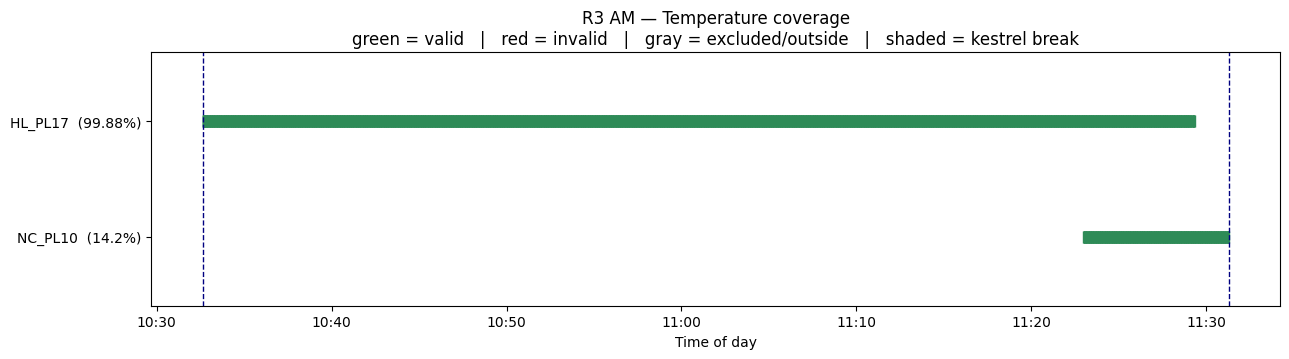

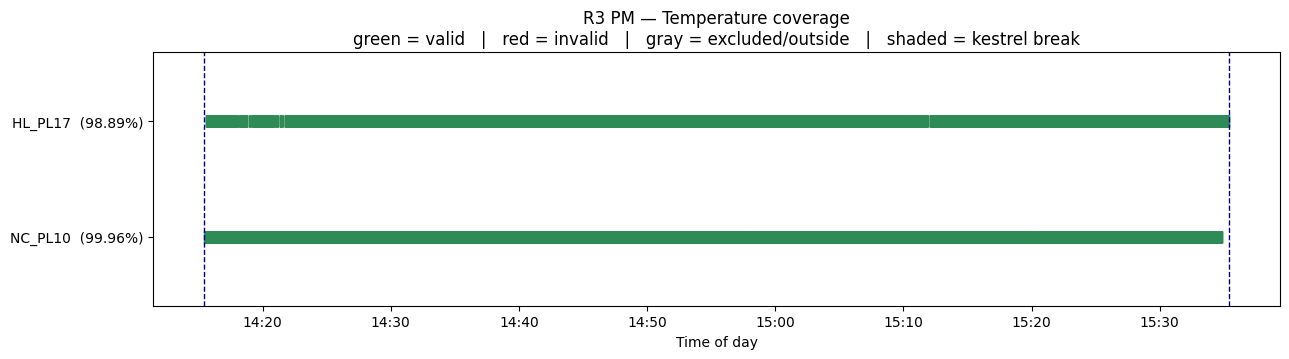

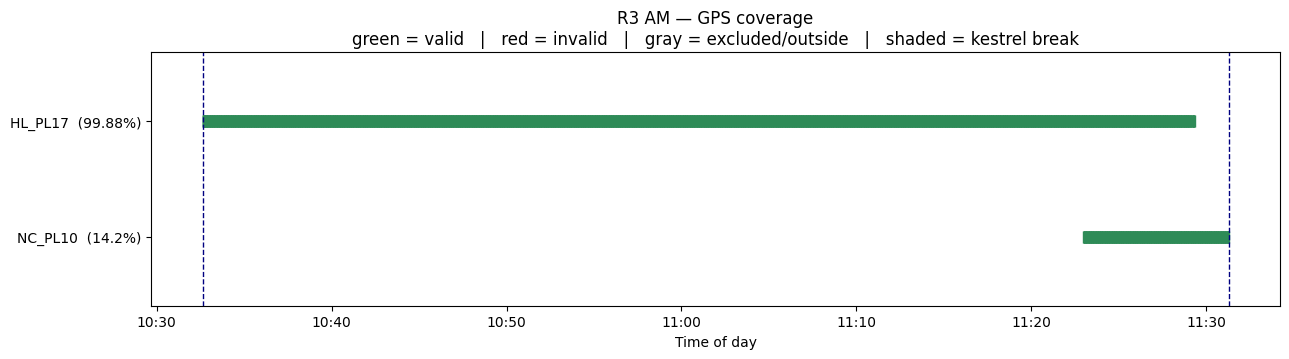

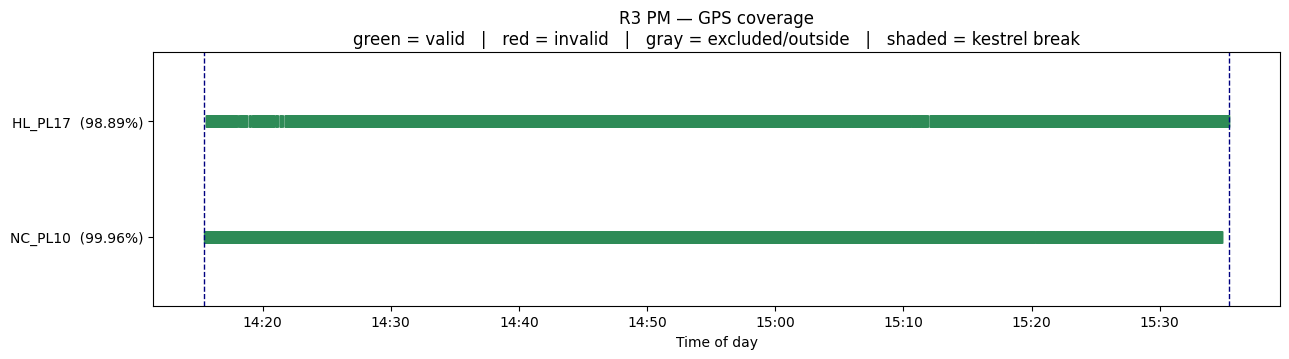

In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_coverage(folder, metric):
    """metric = 'temp' or 'gps'.  One 8imeline per route+AM/PM.
    Each pocketlab is one row of vertical ticks over time:
        green = valid reading (counted)
        red   = reading present but invalid (counted)
        gray  = outside the counted span / inside a kestrel break
    Shaded gray bands = route-wide kestrel breaks (excluded).
    Dashed navy lines = route start / end.
    The % in each row label is what the table reports, so you can eyeball
    whether the green coverage matches the number."""
    label = "Temperature" if metric == "temp" else "GPS"
    pct_key = f"{metric}_pct"

    for g in group_analysis(folder):
        members = g["members"]
        fig, ax = plt.subplots(figsize=(13, 0.85 * len(members) + 2))

        for i, m in enumerate(members):
            ts = m["ts"]
            valid = m[metric] & m["counted"]
            invalid = (~m[metric]) & m["counted"]
            outside = ~m["counted"]
            ax.plot(ts[outside], [i] * int(outside.sum()), "|", color="lightgray", ms=7)
            ax.plot(ts[invalid], [i] * int(invalid.sum()), "|", color="crimson", ms=9)
            ax.plot(ts[valid], [i] * int(valid.sum()), "|", color="seagreen", ms=9)

        # shade the kestrel break windows (excluded from the % denominator)
        for w in g["windows"]:
            ax.axvspan(w[0], w[1], color="0.6", alpha=0.30, zorder=0)

        # route start / end reference lines
        ax.axvline(g["true_start"], color="navy", ls="--", lw=1)
        ax.axvline(g["true_end"], color="navy", ls="--", lw=1)

        ax.set_yticks(range(len(members)))
        ax.set_yticklabels([f'{m["label"]}  ({m[pct_key]}%)' for m in members])
        ax.set_ylim(-0.6, len(members) - 0.4)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.set_xlabel("Time of day")
        ax.set_title(
            f'R{g["route"]} {g["ampm"]} \u2014 {label} coverage\n'
            "green = valid   |   red = invalid   |   gray = excluded/outside   |   shaded = kestrel break"
        )
        fig.tight_layout()


plot_coverage(FOLDER, "temp")
plot_coverage(FOLDER, "gps")
plt.show()